# AMHS 반송 시뮬레이션 & 디스패칭 알고리즘 비교

`amhs/`에 구현한 SimPy 이산사건 시뮬레이션으로, OHT 차량이 8개 공정 스테이션 사이를 오가며 FOUP(웨이퍼 로트)을 반송하는 상황을 재현한다. 목표는 두 가지:

1. **디스패칭 정책 비교** — 같은 차량 대수/부하 조건에서 최근접 차량 / FCFS / 구역기반 배정이 평균 반송 시간(Cycle Time)과 차량 가동률을 어떻게 바꾸는지
2. **차량 대수 민감도** — 차량을 늘리면 반송 시간이 어떻게 줄어드는지(그리고 어디서 한계효용이 꺾이는지)

정책/차량 대수를 제외한 모든 조건(스테이션 처리시간 분포, FOUP 도착 간격, 난수 시드)은 동일하게 고정해 비교가 공정하도록 했다.

In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from amhs import (
    STATION_ORDER, STATIONS,
    run_simulation, nearest_vehicle_dispatch, fcfs_dispatch, zone_based_dispatch,
)

MODELS_DIR = ROOT_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

print("stations (반송 순서):")
for name in STATION_ORDER:
    s = STATIONS[name]
    print(f"  {s.index}. {s.name_ko:>8} ({name}) — 평균 처리시간 {s.process_time_mean_sec:.0f}초")

stations (반송 순서):
  0.   웨이퍼 제조 (wafer_fabrication) — 평균 처리시간 180초
  1.       산화 (oxidation) — 평균 처리시간 195초
  2.       포토 (photolithography) — 평균 처리시간 210초
  3.       식각 (etching) — 평균 처리시간 225초
  4.       증착 (deposition) — 평균 처리시간 240초
  5.    금속 배선 (metallization) — 평균 처리시간 255초
  6.      EDS (eds) — 평균 처리시간 270초
  7.      패키징 (packaging) — 평균 처리시간 285초


## 1. 기본 시나리오 (최근접 차량 배정)

차량 5대, FOUP 25개가 각 2바퀴(=16회 스테이션 통과)씩 도는 시나리오.

In [2]:
BASE_PARAMS = dict(n_vehicles=5, n_foups=25, n_laps=2, foup_launch_interval_sec=150.0, seed=42)

baseline = run_simulation(dispatch_policy=nearest_vehicle_dispatch, **BASE_PARAMS)

print(f"완료율: {baseline['completion_rate']:.2%} ({baseline['completed_transports']}/{baseline['expected_transports']})")
print(f"평균 반송 시간: {baseline['avg_cycle_time_sec']:.1f}초")
print(f"P95 반송 시간: {baseline['p95_cycle_time_sec']:.1f}초")
print(f"평균 차량 가동률: {baseline['avg_vehicle_utilization']:.2%}")
baseline["transport_log"].head()

완료율: 100.00% (400/400)
평균 반송 시간: 366.7초
P95 반송 시간: 633.0초
평균 차량 가동률: 55.71%


,foup_id,from,to,requested_at,completed_at,cycle_time_sec,vehicle_id
0,0,wafer_fabrication,oxidation,159.200318,211.563954,52.363636,0
1,0,oxidation,photolithography,421.572978,473.936615,52.363636,0
2,1,wafer_fabrication,oxidation,501.610587,699.428769,197.818182,4
3,0,photolithography,etching,686.493423,738.857059,52.363636,0
4,2,wafer_fabrication,oxidation,675.285735,909.467553,234.181818,3


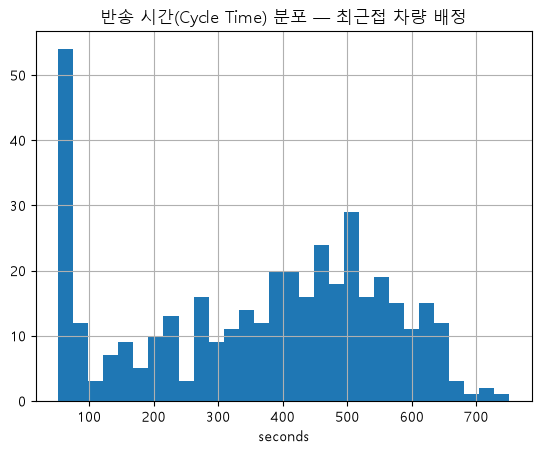

In [3]:
baseline["transport_log"]["cycle_time_sec"].hist(bins=30)
plt.title("반송 시간(Cycle Time) 분포 — 최근접 차량 배정")
plt.xlabel("seconds")
plt.show()

## 2. 디스패칭 정책 비교

동일한 `BASE_PARAMS`로 정책만 바꿔 3회 실행한다.

In [4]:
policies = {
    "nearest_vehicle": nearest_vehicle_dispatch,
    "fcfs": fcfs_dispatch,
    "zone_based": zone_based_dispatch,
}

policy_results = {}
rows = []
for name, policy in policies.items():
    result = run_simulation(dispatch_policy=policy, **BASE_PARAMS)
    policy_results[name] = result
    rows.append({
        "policy": name,
        "completion_rate": result["completion_rate"],
        "avg_cycle_time_sec": round(result["avg_cycle_time_sec"], 1),
        "p95_cycle_time_sec": round(result["p95_cycle_time_sec"], 1),
        "avg_vehicle_utilization": round(result["avg_vehicle_utilization"], 4),
    })

policy_comparison = pd.DataFrame(rows)
policy_comparison

,policy,completion_rate,avg_cycle_time_sec,p95_cycle_time_sec,avg_vehicle_utilization
0,nearest_vehicle,1.0,366.7,633.0,0.5571
1,fcfs,1.0,403.8,676.3,0.6123
2,zone_based,1.0,349.5,606.1,0.5812


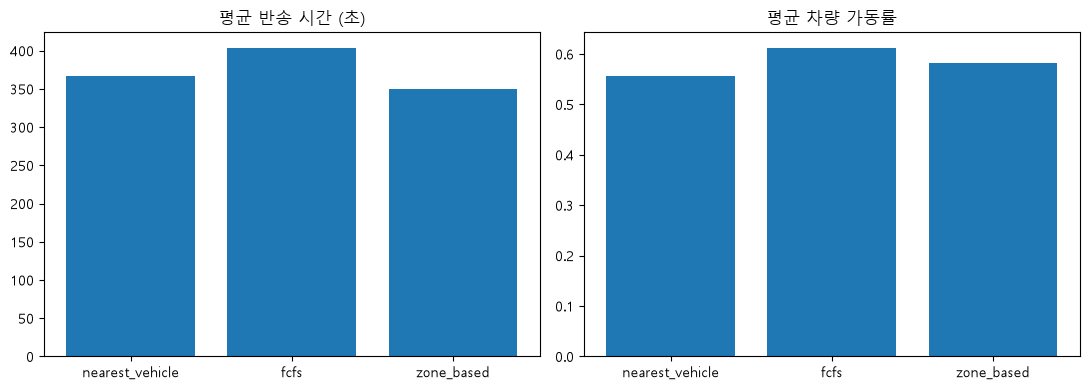

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(policy_comparison["policy"], policy_comparison["avg_cycle_time_sec"])
axes[0].set_title("평균 반송 시간 (초)")
axes[1].bar(policy_comparison["policy"], policy_comparison["avg_vehicle_utilization"])
axes[1].set_title("평균 차량 가동률")
plt.tight_layout()
plt.show()

## 3. 차량 대수 민감도

최근접 차량 배정 정책으로 고정하고, 차량 대수만 2~10대로 바꿔가며 평균 반송 시간이 어떻게 줄어드는지 본다. 차량을 늘리는 데는 실제 비용(구매/유지보수)이 들기 때문에, "몇 대부터 한계효용이 꺾이는가"가 실무적으로 중요한 질문이다.

In [6]:
vehicle_counts = [2, 3, 4, 5, 6, 8, 10]
sensitivity_rows = []
for n in vehicle_counts:
    result = run_simulation(
        n_vehicles=n, n_foups=25, n_laps=2, foup_launch_interval_sec=150.0, seed=42,
        dispatch_policy=nearest_vehicle_dispatch,
    )
    sensitivity_rows.append({
        "n_vehicles": n,
        "avg_cycle_time_sec": result["avg_cycle_time_sec"],
        "avg_vehicle_utilization": result["avg_vehicle_utilization"],
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df

,n_vehicles,avg_cycle_time_sec,avg_vehicle_utilization
0,2,1738.006592,0.969000
1,3,980.325371,0.952300
2,4,578.218503,0.726475
3,5,366.654314,0.557120
4,6,143.881205,0.346733
5,8,66.545455,0.144987
6,10,65.727273,0.114570


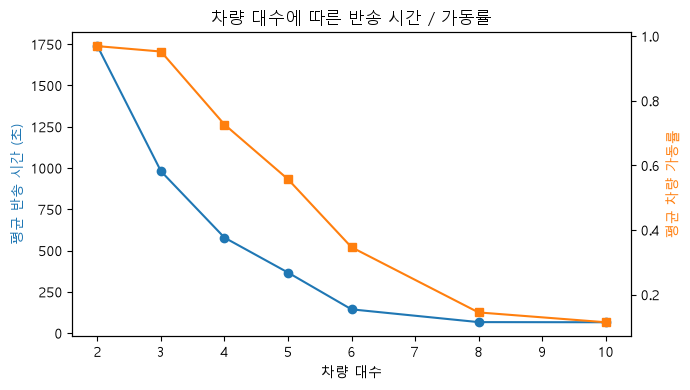

In [7]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(sensitivity_df["n_vehicles"], sensitivity_df["avg_cycle_time_sec"], marker="o", color="tab:blue")
ax1.set_xlabel("차량 대수")
ax1.set_ylabel("평균 반송 시간 (초)", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(sensitivity_df["n_vehicles"], sensitivity_df["avg_vehicle_utilization"], marker="s", color="tab:orange")
ax2.set_ylabel("평균 차량 가동률", color="tab:orange")

plt.title("차량 대수에 따른 반송 시간 / 가동률")
plt.tight_layout()
plt.show()

## 4. 결과 저장

In [8]:
policy_comparison.to_csv(MODELS_DIR / "amhs_dispatch_policy_comparison.csv", index=False)
sensitivity_df.to_csv(MODELS_DIR / "amhs_vehicle_sensitivity.csv", index=False)
baseline["transport_log"].to_csv(MODELS_DIR / "amhs_baseline_transport_log.csv", index=False)
print("저장 완료")

저장 완료


## 결론

**디스패칭 정책 비교** (차량 5대, FOUP 25개 x 2바퀴, 동일 시드):

| 정책 | 평균 반송 시간 | P95 반송 시간 | 평균 가동률 |
|---|---|---|---|
| FCFS (위치 무시) | 403.8초 | 676.3초 | 0.612 |
| 최근접 차량 | 366.7초 | 633.0초 | 0.557 |
| 구역기반 | **349.5초** | **606.1초** | 0.581 |

위치를 고려하는 정책(최근접/구역기반)이 FCFS 대비 평균 반송 시간을 **9~13% 단축**했다. 구역기반이 최근접보다도 약간 더 좋았는데, 8개 스테이션이 골고루 부하를 받는 이 시나리오에서는 차량이 자기 구역에 머물며 대기하는 것이 매번 전역 최적(순간의 최단거리)을 쫓는 것보다 평균적으로 이동 낭비가 적었기 때문으로 보인다. FCFS는 완료율은 같아도(1.0) 가동률이 가장 높다 — 즉 **더 많이 움직이고도 더 늦게 도착**했다는 뜻이라, 정책 품질이 곧 차량 효율이라는 걸 보여준다.

**차량 대수 민감도** (최근접 배정 고정): 2대(1738초)→3대(980초)→4대(578초)→5대(367초)→6대(144초)로 가파르게 줄다가, 6대→8대(144→67초) 이후로는 8대→10대가 거의 그대로(67→66초)다. **6~8대 구간에서 한계효용이 꺾인다** — 그 이후엔 차량을 더 투입해도 스테이션 처리 시간 자체가 병목이라 반송 시간이 거의 안 줄어든다. 가동률도 6대에서 0.35, 10대에서 0.11까지 떨어져 "차량이 남아돈다"는 걸 같이 보여준다. 실무라면 이 지점(6~8대)이 투자 대비 효과가 꺾이는 지점이라는 근거로 쓸 수 있다.